In [16]:
import pandas as pd

In [17]:
data = pd.read_csv('/content/income.csv')

In [18]:
data.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       22 non-null     object
 1   Age        22 non-null     int64 
 2   Income($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [20]:
data.describe()

,Age,Income($)
count,22.000000,22.000000
mean,34.818182,90431.818182
std,5.901060,43505.964412
min,26.000000,45000.000000
25%,29.000000,58500.000000
50%,36.500000,67500.000000
75%,39.750000,135250.000000
max,43.000000,162000.000000


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
sc = StandardScaler()

In [23]:
data.loc[:,['Age','Income($)']] = sc.fit_transform(data.loc[:,['Age','Income($)']])

<ipython-input-23-49eb12be6ce4>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.35605536 -1.00915747 -1.00915747 -1.18260641  1.24567876  0.72533193
  1.07222982  0.55188299  0.20498511  0.03153617  0.37843405 -1.5295043
 -1.35605536 -1.18260641 -1.00915747 -0.48881065  0.89878087  1.07222982
  1.4191277   0.72533193  1.07222982  0.72533193]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:,['Age','Income($)']] = sc.fit_transform(data.loc[:,['Age','Income($)']])
<ipython-input-23-49eb12be6ce4>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.48068427 -0.01015907 -0.69242061 -0.71594687  1.40141653  1.51904783
  1.63667914  1.68373166  1.54257409  0.93089133  1.09557515 -1.06884077
 -0.99826199 -0.92768321 -0.9629726  -0.88063069 -0.59831557 -0.64536809
 -0.62184183 -0.24542167 -0.19836

In [24]:
data.head()

,Name,Age,Income($)
0,Rob,-1.356055,-0.480684
1,Michael,-1.009157,-0.010159
2,Mohan,-1.009157,-0.692421
3,Ismail,-1.182606,-0.715947
4,Kory,1.245679,1.401417


In [25]:
import matplotlib.pyplot as plt

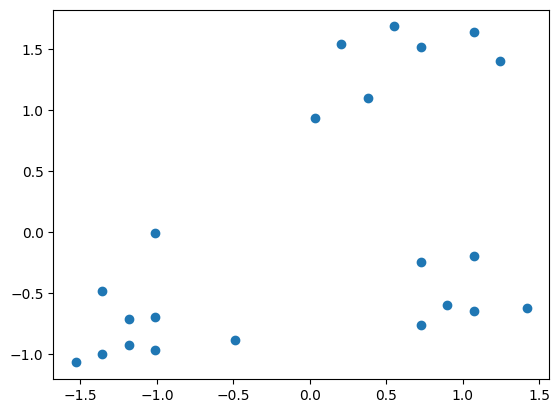

In [30]:
plt.scatter(x=data.loc[:,'Age'],y=data.loc[:,'Income($)'])

In [31]:
from sklearn.cluster import KMeans

In [32]:
model = KMeans(n_clusters=3)

In [33]:
target = model.fit_predict(data.loc[:,['Age','Income($)']])

In [34]:
target

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [36]:
data.loc[:,'target']=target

In [37]:
data.head()

,Name,Age,Income($),target
0,Rob,-1.356055,-0.480684,1
1,Michael,-1.009157,-0.010159,1
2,Mohan,-1.009157,-0.692421,1
3,Ismail,-1.182606,-0.715947,1
4,Kory,1.245679,1.401417,0


In [38]:
model.cluster_centers_

array([[ 0.60143983,  1.40141653],
       [-1.1247901 , -0.74862223],
       [ 0.98550535, -0.51205261]])

In [39]:
model.labels_

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [40]:
data[data.loc[:,'target']==0].Age

,Age
4,1.245679
5,0.725332
6,1.072230
7,0.551883
8,0.204985
9,0.031536
10,0.378434


In [41]:
center= model.cluster_centers_

In [42]:
center

array([[ 0.60143983,  1.40141653],
       [-1.1247901 , -0.74862223],
       [ 0.98550535, -0.51205261]])

In [43]:
center[:,0]

array([ 0.60143983, -1.1247901 ,  0.98550535])

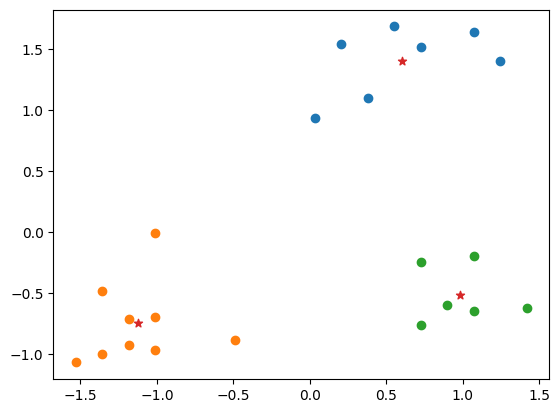

In [44]:
plt.scatter(data[data.loc[:,'target']==0].Age, data[data.loc[:,'target']==0]['Income($)'])
plt.scatter(data[data.loc[:,'target']==1].Age, data[data.loc[:,'target']==1]['Income($)'])
plt.scatter(data[data.loc[:,'target']==2].Age, data[data.loc[:,'target']==2]['Income($)'])
plt.scatter(center[:,0], center[:,1], marker='*')
